In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Credit Score Classification Dataset.csv')
df

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25,Female,50000,Bachelor's Degree,Single,0,Rented,High
1,30,Male,100000,Master's Degree,Married,2,Owned,High
2,35,Female,75000,Doctorate,Married,1,Owned,High
3,40,Male,125000,High School Diploma,Single,0,Owned,High
4,45,Female,100000,Bachelor's Degree,Married,3,Owned,High
...,...,...,...,...,...,...,...,...
159,29,Female,27500,High School Diploma,Single,0,Rented,Low
160,34,Male,47500,Associate's Degree,Single,0,Rented,Average
161,39,Female,62500,Bachelor's Degree,Married,2,Owned,High
162,44,Male,87500,Master's Degree,Single,0,Owned,High


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 164 non-null    int64 
 1   Gender              164 non-null    object
 2   Income              164 non-null    int64 
 3   Education           164 non-null    object
 4   Marital Status      164 non-null    object
 5   Number of Children  164 non-null    int64 
 6   Home Ownership      164 non-null    object
 7   Credit Score        164 non-null    object
dtypes: int64(3), object(5)
memory usage: 10.4+ KB


In [4]:
df.isnull().sum()

Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64

In [5]:
df.dropna(subset=['Credit Score'], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 164 non-null    int64 
 1   Gender              164 non-null    object
 2   Income              164 non-null    int64 
 3   Education           164 non-null    object
 4   Marital Status      164 non-null    object
 5   Number of Children  164 non-null    int64 
 6   Home Ownership      164 non-null    object
 7   Credit Score        164 non-null    object
dtypes: int64(3), object(5)
memory usage: 10.4+ KB


In [7]:
import plotly.express as px
import matplotlib.pyplot as plt


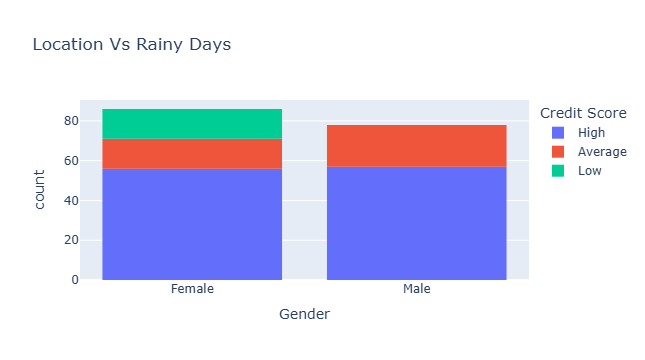

array(["Bachelor's Degree", "Master's Degree", 'Doctorate',
       'High School Diploma', "Associate's Degree"], dtype=object)

In [8]:
fig = px.histogram(df,x='Gender', title='Location Vs Rainy Days', color='Credit Score')
fig.show()

df.Education.unique()

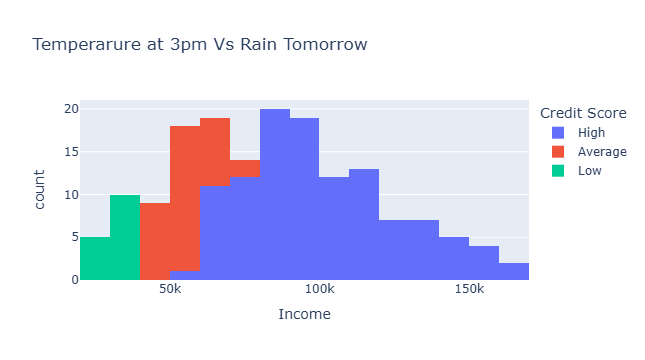

In [9]:
px.histogram(df, x='Income', color='Credit Score', title='Temperarure at 3pm Vs Rain Tomorrow')

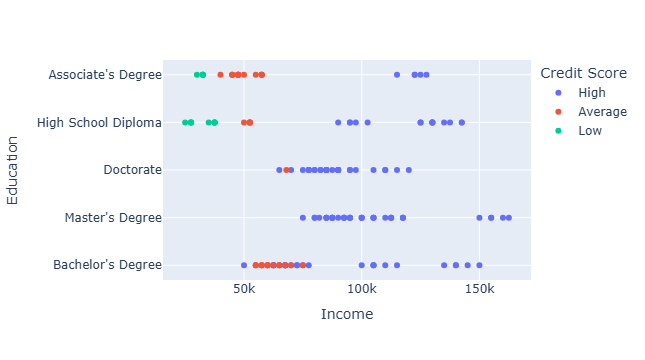

In [10]:
fig = px.scatter(df, x='Income', y='Education', color='Credit Score')
fig.show()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

train_df, test_df = train_test_split(df, test_size=0.25)

In [13]:
print(train_df.shape)
print(test_df.shape)

(123, 8)
(41, 8)


In [14]:
input_cols = list(train_df.columns)[0:-1]
target_cols = 'Credit Score'

input_cols

['Age',
 'Gender',
 'Income',
 'Education',
 'Marital Status',
 'Number of Children',
 'Home Ownership']

In [15]:
target_cols

'Credit Score'

In [16]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_cols].copy()

train_targets

4         High
24         Low
125    Average
96        High
1         High
        ...   
68     Average
54     Average
65        High
41         Low
82        High
Name: Credit Score, Length: 123, dtype: object

In [17]:
test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_cols].copy()

In [18]:
import numpy as np

numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

categorical_cols

['Gender', 'Education', 'Marital Status', 'Home Ownership']

In [19]:
numeric_cols

['Age', 'Income', 'Number of Children']

In [20]:
train_inputs.describe()

,Age,Income,Number of Children
count,123.000000,123.000000,123.000000
mean,37.471545,81219.512195,0.707317
std,8.203683,31540.381763,0.911958
min,25.000000,25000.000000,0.000000
25%,30.000000,57500.000000,0.000000
50%,36.000000,80000.000000,0.000000
75%,44.500000,98750.000000,1.000000
max,53.000000,162500.000000,3.000000


In [21]:
train_inputs[categorical_cols].nunique()

Gender            2
Education         5
Marital Status    2
Home Ownership    2
dtype: int64

In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = 'mean')

df[numeric_cols].isna().sum()

Age                   0
Income                0
Number of Children    0
dtype: int64

In [23]:
train_df[numeric_cols].isna().sum()

Age                   0
Income                0
Number of Children    0
dtype: int64

In [24]:
imputer.fit(df[numeric_cols])

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [25]:
list(imputer.statistics_)

[np.float64(37.97560975609756),
 np.float64(83765.24390243902),
 np.float64(0.6524390243902439)]

In [26]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [27]:
df[numeric_cols].describe()

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.975610,83765.243902,0.652439
std,8.477289,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,30.750000,57500.000000,0.000000
50%,37.000000,83750.000000,0.000000
75%,45.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


In [28]:
from sklearn.preprocessing import MinMaxScaler

In [29]:
scaler = MinMaxScaler()

In [30]:
scaler.fit(df[numeric_cols])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [31]:
list(scaler.data_min_)


[np.float64(25.0), np.float64(25000.0), np.float64(0.0)]

In [32]:
list(scaler.data_max_)

[np.float64(53.0), np.float64(162500.0), np.float64(3.0)]

In [33]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [34]:
train_inputs[numeric_cols].describe()

,Age,Income,Number of Children
count,123.000000,123.000000,123.000000
mean,0.445412,0.408869,0.235772
std,0.292989,0.229385,0.303986
min,0.000000,0.000000,0.000000
25%,0.178571,0.236364,0.000000
50%,0.392857,0.400000,0.000000
75%,0.696429,0.536364,0.333333
max,1.000000,1.000000,1.000000


In [35]:
df[categorical_cols].nunique()

Gender            2
Education         5
Marital Status    2
Home Ownership    2
dtype: int64

In [46]:
from sklearn.preprocessing import OneHotEncoder

In [47]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


In [48]:

single_cat_cols = [col for col in categorical_cols if df[col].nunique() == 2]
multi_cat_cols = [col for col in categorical_cols if df[col].nunique() > 2]



In [50]:
encoder.fit(df[multi_cat_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [55]:
encoded_names = list(encoder.get_feature_names_out(multi_cat_cols))
encoded_names

["Education_Associate's Degree",
 "Education_Bachelor's Degree",
 'Education_Doctorate',
 'Education_High School Diploma',
 "Education_Master's Degree"]

In [58]:
train_inputs[encoded_names] = encoder.transform(train_inputs[multi_cat_cols])
test_inputs[encoded_names] = encoder.transform(test_inputs[multi_cat_cols])

In [59]:
test_inputs

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
60,0.357143,Female,0.436364,Doctorate,Married,0.333333,Owned,0.0,0.0,1.0,0.0,0.0
57,0.857143,Female,0.381818,Doctorate,Married,0.333333,Owned,0.0,0.0,1.0,0.0,0.0
59,0.178571,Male,0.636364,Master's Degree,Married,0.666667,Owned,0.0,0.0,0.0,0.0,1.0
115,0.821429,Female,0.454545,Doctorate,Married,0.333333,Owned,0.0,0.0,1.0,0.0,0.0
47,0.107143,Female,0.054545,Associate's Degree,Single,0.000000,Rented,1.0,0.0,0.0,0.0,0.0
58,0.000000,Female,0.236364,Bachelor's Degree,Single,0.000000,Rented,0.0,1.0,0.0,0.0,0.0
140,0.892857,Male,0.945455,Master's Degree,Married,0.000000,Owned,0.0,0.0,0.0,0.0,1.0
91,0.178571,Male,0.636364,Master's Degree,Married,0.666667,Owned,0.0,0.0,0.0,0.0,1.0
78,0.964286,Male,0.800000,High School Diploma,Married,0.000000,Owned,0.0,0.0,0.0,1.0,0.0
27,0.678571,Male,0.363636,Master's Degree,Single,0.000000,Owned,0.0,0.0,0.0,0.0,1.0


In [74]:
from sklearn.preprocessing import LabelEncoder

In [75]:
le = LabelEncoder()

In [85]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Initialize
oe = OrdinalEncoder()

# 2. Fit and transform all columns at once (handles 2D DataFrames!)
train_inputs[single_cat_cols] = oe.fit_transform(train_inputs[single_cat_cols])
test_inputs[single_cat_cols] = oe.fit_transform(test_inputs[single_cat_cols])

In [86]:
train_inputs[single_cat_cols]

,Gender,Marital Status,Home Ownership
4,0.0,0.0,0.0
24,0.0,1.0,1.0
125,0.0,1.0,1.0
96,1.0,1.0,0.0
1,1.0,0.0,0.0
...,...,...,...
68,1.0,1.0,1.0
54,1.0,1.0,1.0
65,0.0,0.0,0.0
41,0.0,1.0,1.0


In [91]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [92]:
final_feature = numeric_cols + single_cat_cols + encoded_names

In [93]:
model.fit(train_inputs[final_feature], train_targets)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [94]:
train_targets

4         High
24         Low
125    Average
96        High
1         High
        ...   
68     Average
54     Average
65        High
41         Low
82        High
Name: Credit Score, Length: 123, dtype: object

In [95]:
print(numeric_cols + encoded_names)

['Age', 'Income', 'Number of Children', "Education_Associate's Degree", "Education_Bachelor's Degree", 'Education_Doctorate', 'Education_High School Diploma', "Education_Master's Degree"]


In [127]:
X_train = train_inputs[final_feature]
X_test = test_inputs[final_feature]

In [128]:
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)
print(train_preds)

['High' 'Low' 'Average' 'High' 'High' 'Average' 'High' 'High' 'High'
 'High' 'High' 'High' 'High' 'High' 'Average' 'Average' 'High' 'High'
 'High' 'High' 'High' 'High' 'Average' 'High' 'Low' 'High' 'High' 'High'
 'Low' 'High' 'High' 'High' 'High' 'Average' 'High' 'Average' 'Low' 'High'
 'High' 'High' 'High' 'High' 'High' 'High' 'High' 'High' 'Average' 'High'
 'High' 'High' 'High' 'High' 'Average' 'Low' 'Average' 'Average' 'High'
 'Average' 'High' 'Low' 'High' 'High' 'High' 'High' 'High' 'High' 'High'
 'High' 'Average' 'High' 'High' 'High' 'High' 'Low' 'High' 'Average'
 'High' 'High' 'Average' 'High' 'High' 'High' 'Average' 'Average'
 'Average' 'High' 'High' 'High' 'Average' 'Average' 'High' 'High' 'High'
 'Average' 'High' 'High' 'Average' 'High' 'Average' 'High' 'High' 'High'
 'High' 'Average' 'Average' 'High' 'High' 'Average' 'Average' 'High'
 'High' 'Average' 'High' 'Average' 'Average' 'High' 'High' 'High'
 'Average' 'Average' 'High' 'Low' 'High']


In [129]:
from sklearn.metrics import accuracy_score

In [130]:
accuracy_score(train_targets, train_preds)

0.943089430894309

In [131]:
train_probs = model.predict_proba(X_train)
train_probs

array([[1.87501239e-02, 9.78556578e-01, 2.69329817e-03],
       [1.87217554e-01, 5.93662848e-02, 7.53416161e-01],
       [7.16865948e-01, 1.63100045e-01, 1.20034008e-01],
       [6.97574639e-02, 9.09225914e-01, 2.10166221e-02],
       [1.37826479e-02, 9.85025028e-01, 1.19232363e-03],
       [8.85258197e-01, 6.50020280e-02, 4.97397754e-02],
       [1.38421804e-02, 9.82025970e-01, 4.13184913e-03],
       [1.18028410e-02, 9.87254082e-01, 9.43077101e-04],
       [1.35969303e-02, 9.38017529e-01, 4.83855411e-02],
       [1.93970554e-02, 9.77586708e-01, 3.01623695e-03],
       [2.04430189e-02, 9.66217804e-01, 1.33391773e-02],
       [1.90178643e-02, 9.80712437e-01, 2.69699143e-04],
       [4.07810783e-02, 9.52705410e-01, 6.51351201e-03],
       [1.79438896e-02, 9.79536465e-01, 2.51964582e-03],
       [5.70412366e-01, 4.67250900e-02, 3.82862544e-01],
       [8.90581790e-01, 6.29153838e-02, 4.65028258e-02],
       [8.80683640e-03, 9.84701283e-01, 6.49188082e-03],
       [1.99438148e-02, 9.76603

In [132]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [133]:
confusion_matrix(train_targets, train_preds, normalize='true')

array([[0.96296296, 0.03703704, 0.        ],
       [0.02380952, 0.97619048, 0.        ],
       [0.33333333, 0.        , 0.66666667]])

In [134]:
import seaborn as sns

def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Targets')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 94.31%


array(['High', 'Low', 'Average', 'High', 'High', 'Average', 'High',
       'High', 'High', 'High', 'High', 'High', 'High', 'High', 'Average',
       'Average', 'High', 'High', 'High', 'High', 'High', 'High',
       'Average', 'High', 'Low', 'High', 'High', 'High', 'Low', 'High',
       'High', 'High', 'High', 'Average', 'High', 'Average', 'Low',
       'High', 'High', 'High', 'High', 'High', 'High', 'High', 'High',
       'High', 'Average', 'High', 'High', 'High', 'High', 'High',
       'Average', 'Low', 'Average', 'Average', 'High', 'Average', 'High',
       'Low', 'High', 'High', 'High', 'High', 'High', 'High', 'High',
       'High', 'Average', 'High', 'High', 'High', 'High', 'Low', 'High',
       'Average', 'High', 'High', 'Average', 'High', 'High', 'High',
       'Average', 'Average', 'Average', 'High', 'High', 'High', 'Average',
       'Average', 'High', 'High', 'High', 'Average', 'High', 'High',
       'Average', 'High', 'Average', 'High', 'High', 'High', 'High',
       'Average'

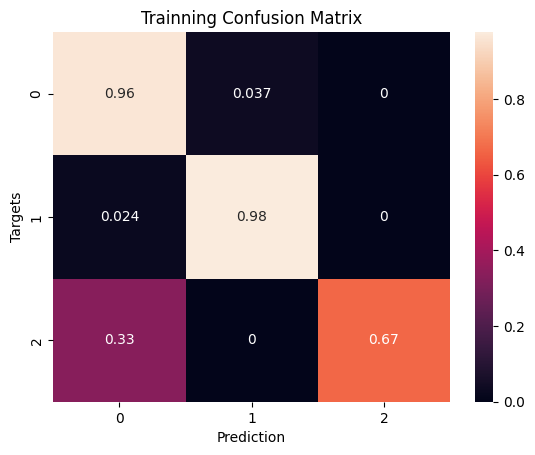

In [135]:
predict_and_plot(X_train, train_targets, 'Trainning')

In [141]:
pre_weighted = precision_score(test_targets, test_preds, average='weighted')
pre_macro = precision_score(test_targets, test_preds, average='macro')
pre_micro = precision_score(test_targets, test_preds, average='micro')

In [148]:
print(f"Weighted Precisiion Score :{pre_weighted:.4f}")
print(f"Macro Precisiion Sccore: {pre_macro:.4f}")
print(f"Micro Precision Score: {pre_micro:.4f}")

Weighted Precisiion Score :0.9317
Macro Precisiion Sccore: 0.9218
Micro Precision Score: 0.9268


In [150]:
from sklearn.metrics import classification_report

print(classification_report(test_targets, test_preds))

              precision    recall  f1-score   support

     Average       0.80      0.89      0.84         9
        High       0.97      0.97      0.97        29
         Low       1.00      0.67      0.80         3

    accuracy                           0.93        41
   macro avg       0.92      0.84      0.87        41
weighted avg       0.93      0.93      0.93        41



In [151]:
import joblib

In [152]:
credit_score_package = {
    'model': model, 
    'onehot_encoder': oe,
    'feature_names':final_feature,
    'numeric_cols':numeric_cols
}

joblib.dump(credit_score_package, 'credit_score_model.joblib')

['credit_score_model.joblib']

In [154]:
test_df
    

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
60,35,Female,85000,Doctorate,Married,1,Owned,High
57,49,Female,77500,Doctorate,Married,1,Owned,High
59,30,Male,112500,Master's Degree,Married,2,Owned,High
115,48,Female,87500,Doctorate,Married,1,Owned,High
47,28,Female,32500,Associate's Degree,Single,0,Rented,Low
58,25,Female,57500,Bachelor's Degree,Single,0,Rented,Average
140,50,Male,155000,Master's Degree,Married,0,Owned,High
91,30,Male,112500,Master's Degree,Married,2,Owned,High
78,52,Male,135000,High School Diploma,Married,0,Owned,High
27,44,Male,75000,Master's Degree,Single,0,Owned,High


In [167]:
new_input = {
    'Age': 49,
    'Gender': 'Female',
    'Income': 77500,
    'Education': 'Doctorate',
    'Marital Status' : 'Married',
    'Number of Children': 1,
    'Home Ownership': 'Owned',
}

In [168]:
new_input_df = pd.DataFrame([new_input])
new_input_df

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership
0,49,Female,77500,Doctorate,Married,1,Owned


In [169]:
new_input_df[numeric_cols] = imputer.transform(new_input_df[numeric_cols])
new_input_df[numeric_cols] = scaler.transform(new_input_df[numeric_cols])
new_input_df[single_cat_cols] = oe.fit_transform(new_input_df[single_cat_cols])
new_input_df[encoded_names] = encoder.transform(new_input_df[multi_cat_cols])

In [170]:
X_new_input = new_input_df[numeric_cols + single_cat_cols + encoded_names]

In [171]:
predict = model.predict(X_new_input)
predict

array(['High'], dtype=object)